# RadCluster_1_0  Cluster Dynamics for Irradiated Materials

Full per-size cluster dynamics model implementing:
- **Master equations** (Eqs. 152, 155, 157) for SIA clusters, He-vacancy bubbles, and free He.
- **He-reduction**: Case 2 fission (Eq. 175, decoupled) or Case 1 fusion (Eq. 174, mean-field).
- **Size-bin moments** (Chapter 9, Eqs. 188â€“211) for large-N efficiency.
- **Solute trapping** in EUROFER97 (Cr, W, Mn, C, N) via effective diffusivities (Eqs. 42, 48, 52).
- **1D/3D mixed transport** for glissile SIA clusters (Eq. 141).

Physics reference: Ghoniem, N.M. (2026), *'A Cluster Dynamics Model for Radiation Damage Evolution in Ferritic-Martensitic Steels'* (Rate_Equations.pdf).

---

## Solver modes
| `solver_mode` | Description |
|---|---|
| `cpp_full` | C++ CVODE BDF, full system, dense/band/GMRES |
| `cpp_sliding_win` | C++ CVODE BDF with sliding SIA window (Phase III) |
| `sliding_OpenMP` | Sliding window + OpenMP intra-RHS parallelism (Phase IV) |

## Physics options
| `physics_option` | Equations | He reduction | Cascade |
|---|---|---|---|
| `full_CD_fission` | Eqs. 152, 155, 157 | Case 2, Eq. 175 (decoupled) | Fission (Table 2) |
| `full_CD_fusion` | Eqs. 152, 155, 157 | Case 1, Eq. 174 (mean-field) | Fusion (Table 2) |
| `bin_moment_CD_fission` | Chapter 9 moments | Case 2 | Fission |
| `bin_moment_CD_fusion` | Chapter 9 moments | Case 1 | Fusion |

## Build C++ solver (run once after code changes)

In [ ]:
import sys, os, subprocess
from pathlib import Path

# Add RadCluster_1_0 root to path
MODULE_ROOT = Path('../..').resolve()
REPO_ROOT   = MODULE_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print(f'Module root: {MODULE_ROOT}')
print(f'Repo root:   {REPO_ROOT}')

# ---------------------------------------------------------------------------
# Build the C++ SUNDIALS solver only if the platform-correct binary is
# missing. This makes the notebook portable across macOS / Linux / Windows:
# moving between OSes leaves the wrong-platform binary in build/ and the
# Python bridge cannot launch it, so we rebuild on first run for the new OS.
# Set FORCE_REBUILD = True to force a rebuild after C++ source changes.
# ---------------------------------------------------------------------------
FORCE_REBUILD = False

build_dir = MODULE_ROOT / 'build'
exe_name  = 'solver.exe' if sys.platform == 'win32' else 'solver'
exe_candidates = [
    build_dir / 'Release' / exe_name,
    build_dir / 'Debug'   / exe_name,
    build_dir              / exe_name,
]
exe_found = next((p for p in exe_candidates if p.exists()), None)

if exe_found is not None and not FORCE_REBUILD:
    print(f'C++ solver already built: {exe_found}')
    print('Set FORCE_REBUILD = True to rebuild after C++ source changes.')
else:
    if exe_found is None:
        print(f'No {exe_name} found under {build_dir} -- building now ...')
    else:
        print(f'FORCE_REBUILD set -- rebuilding {exe_found} ...')

    build_dir.mkdir(exist_ok=True)
    cmake_src  = MODULE_ROOT / 'cpp_utils'
    cmake_cmd  = ['cmake', '-S', str(cmake_src), '-B', str(build_dir),
                   '-DCMAKE_BUILD_TYPE=Release']
    build_cmd  = ['cmake', '--build', str(build_dir), '--config', 'Release']

    for cmd in [cmake_cmd, build_cmd]:
        res = subprocess.run(cmd, capture_output=True, text=True)
        print(' '.join(cmd))
        if res.returncode != 0:
            print('STDERR:', res.stderr[-2000:])
            raise RuntimeError(f'Build step failed: {cmd[0]} {cmd[1]}')
        else:
            print('OK')
            print(res.stdout[-500:])

    exe_found = next((p for p in exe_candidates if p.exists()), None)
    if exe_found is None:
        raise RuntimeError(f'Build completed but no {exe_name} found under {build_dir}')
    print(f'Built: {exe_found}')


## MAIN SIMULATION SCRIPT

### Bin-moment system size (N_eq)

The total number of ODEs depends on `I`, `V`, `i_discrete`, `I_bin`, `V_bin`, and the He mode:

```
i_discrete = max discrete SIA size (individually tracked)
v_discrete = max discrete vacancy size (individually tracked)
I_bin      = number of SIA bin-moment equations beyond i_discrete
V_bin      = number of VAC bin-moment equations beyond v_discrete
```

| Component | ODEs | Description |
|---|---|---|
| Discrete SIA | i_discrete | individual c_i for i=1..i_discrete |
| Binned SIA moments | 2 × I_bin | zeroth + first moment per bin |
| Discrete VAC | v_discrete | individual c_v for v=1..v_discrete |
| Binned VAC moments | 2 × V_bin | zeroth + first moment per bin (hat-function closure) |
| He state | 1 (fission/Case 2) or V_bin (fusion/Case 1) | Q_tot scalar or Q_k per bin |
| Free He | 0 (QSS) or 1 (dynamic) | quasi-steady-state eliminates this |
| **Total N_eq** | **i_discrete + 2·I_bin + v_discrete + 2·V_bin + 1** (fission, QSS) | |

**Limiting cases:**
- When `I_bin=0` and `i_discrete=I` → all SIA equations are discrete (full_CD recovery)
- When `V_bin=0` and `v_discrete=V` → all VAC equations are discrete

**Examples** (fission, QSS He, i_discrete=i_mobile=11, v_discrete=v_mobile=5):

| I | V | I_bin | V_bin | N_eq |
|---|---|---|---|---|
| 10,000 | 10,000 | 10 | 13 | 63 |
| 100,000 | 100,000 | 13 | 16 | 74 |
| 1,000,000 | 1,000,000 | 17 | 19 | 88 |

Compare with full_CD: N_eq = I + V + 2 (fission), so I=V=10,000 → **20,002 ODEs**.

Applied 16 parameter overrides:
           eta = 0.3
        f_cl_i = 0.2
        f_cl_v = 0.15
        E_m_1D = 0.4
      i_mobile = 1
         L_hat = 5
           c_C = 0.001
     E_b_C_SIA = 0.65
         rho_d = 1000000000000000.0
           Z_i = 1.08
          Z_ii = 1.01
  shape_function = linear
    i_discrete = 10000
    v_discrete = 10000
         I_bin = 0
         V_bin = 0

Full per-size system: N_eq = 20006

Launching solver_mode='cpp_full' …
C++ solver: solver.exe  N_eq=20006  solver_mode='cpp_full'  physics='full_CD_fission'


Expanded_Eurofer_CD solver: N_eq=20006  physics_option=0  he_mode=0  he_options=quasi_steady_state  C_floor=1e-25  window_mode=0
[cvode] pt=1/200  t=1.16232e-06  steps=7  rhs=10  nlcf=0  etf=0  h=1.33834e-07  ret=0
[cvode] pt=2/200  t=1.351e-06  steps=8  rhs=11  nlcf=0  etf=0  h=2.894e-07  ret=0
[cvode] pt=3/200  t=1.570e-06  steps=9  rhs=12  nlcf=0  etf=0  h=5.561e-07  ret=0
[cvode] pt=4/200  t=1.825e-06  steps=9  rhs=12  nlcf=0  etf=0  h=5.561e-07  ret=0
[cvode] pt=5/200  t=2.121e-06  steps=10  rhs=13  nlcf=0  etf=0  h=1.011e-06  ret=0
[cvode] pt=6/200  t=2.466e-06  steps=10  rhs=13  nlcf=0  etf=0  h=1.011e-06  ret=0
[cvode] pt=7/200  t=2.866e-06  steps=10  rhs=13  nlcf=0  etf=0  h=1.011e-06  ret=0
[cvode] pt=8/200  t=3.331e-06  steps=11  rhs=14  nlcf=0  etf=0  h=1.835e-06  ret=0
[cvode] pt=9/200  t=3.872e-06  steps=11  rhs=14  nlcf=0  etf=0  h=1.835e-06  ret=0
[cvode] pt=10/200  t=4.501e-06  steps=11  rhs=14  nlcf=0  etf=0  h=1.835e-06  ret=0
[cvode] pt=11/200  t=5.231e-06  steps=12

C++ solver completed — 200 time points
Results processing complete.

Final domain: I=10000  V=10000
Solution:         200 time points, t = [1.00e-06, 1.00e+07] s
Final dose:       1.0000e+01 dpa
Swelling (final): 3.182574 %
C_He_tot (final): 7.133e+19 m^-3
mean_n_i (final): 7.98
mean_n_v (final): 4005.14
N_loops  (final): 3.828e+24 m^-3
N_voids  (final): 6.734e+23 m^-3
delta_FP (final): 2.657e-01  (Eq. 164)
delta_He (final): nan  (Eq. 165)
Diagnostics written to: C:\Users\Owner\Documents\Repos\RadCluster\RadCluster_1_0\output\20260502_090430_cpp_full_full_CD_fission_I10000V10000_im1vm1\diagnostics.txt


C:\Users\Owner\Documents\Repos\RadCluster\RadCluster_1_0\py_utils\visualization.py:974: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9))


Saved plots to C:\Users\Owner\Documents\Repos\RadCluster\RadCluster_1_0\output\20260502_090430_cpp_full_full_CD_fission_I10000V10000_im1vm1\plots/
Output written to: C:\Users\Owner\Documents\Repos\RadCluster\RadCluster_1_0\output\20260502_090430_cpp_full_full_CD_fission_I10000V10000_im1vm1


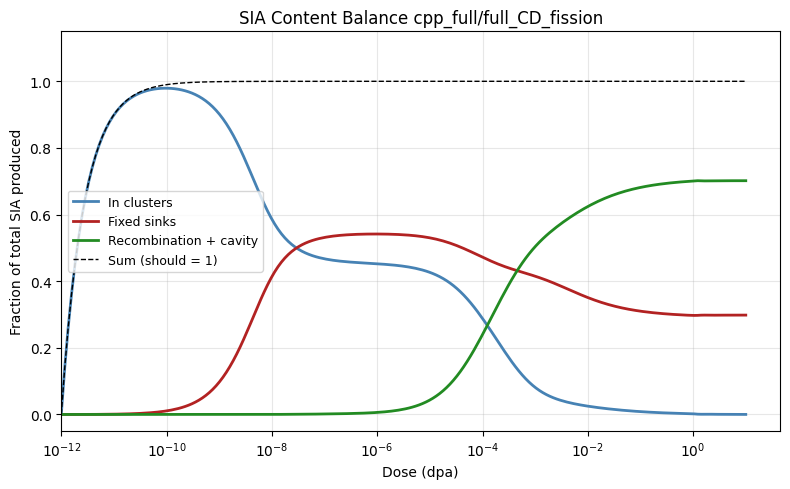

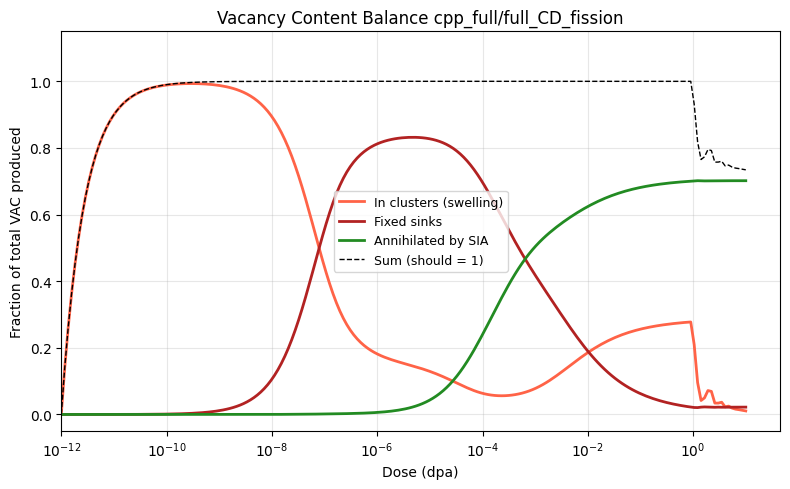

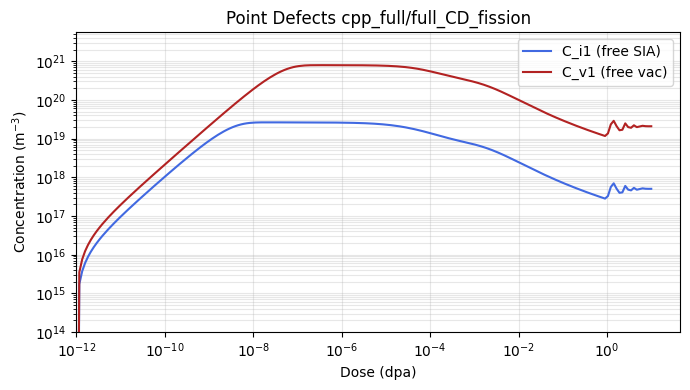

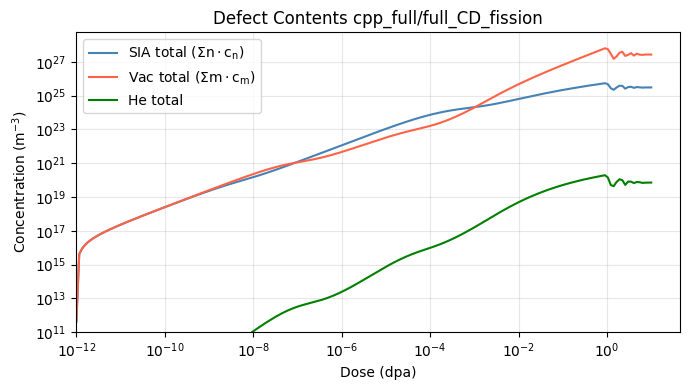

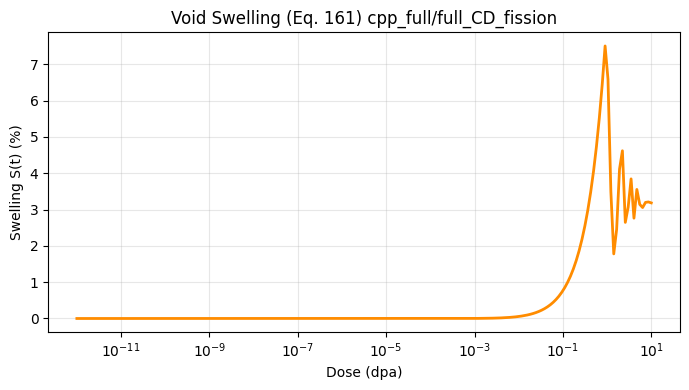

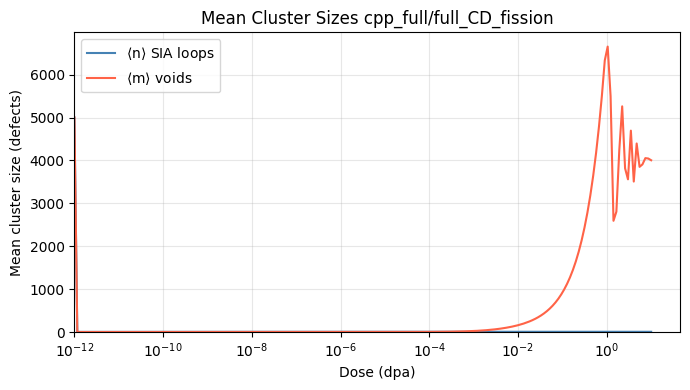

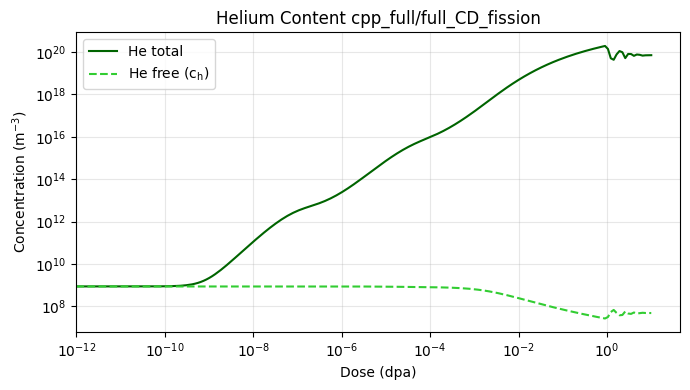

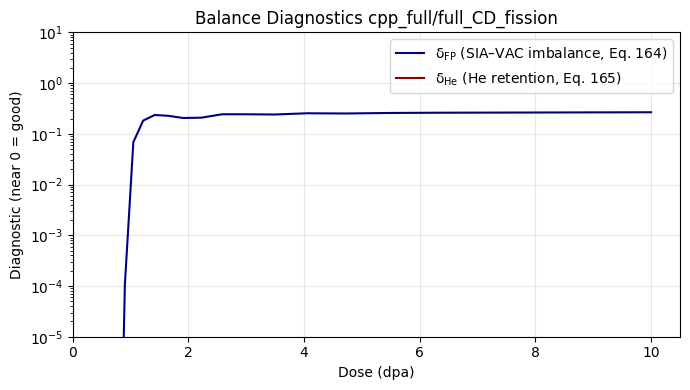

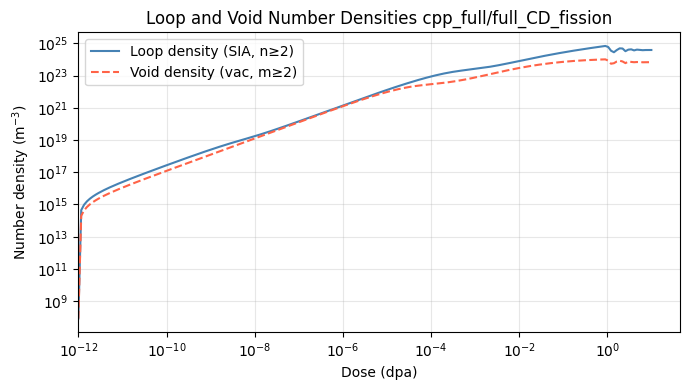

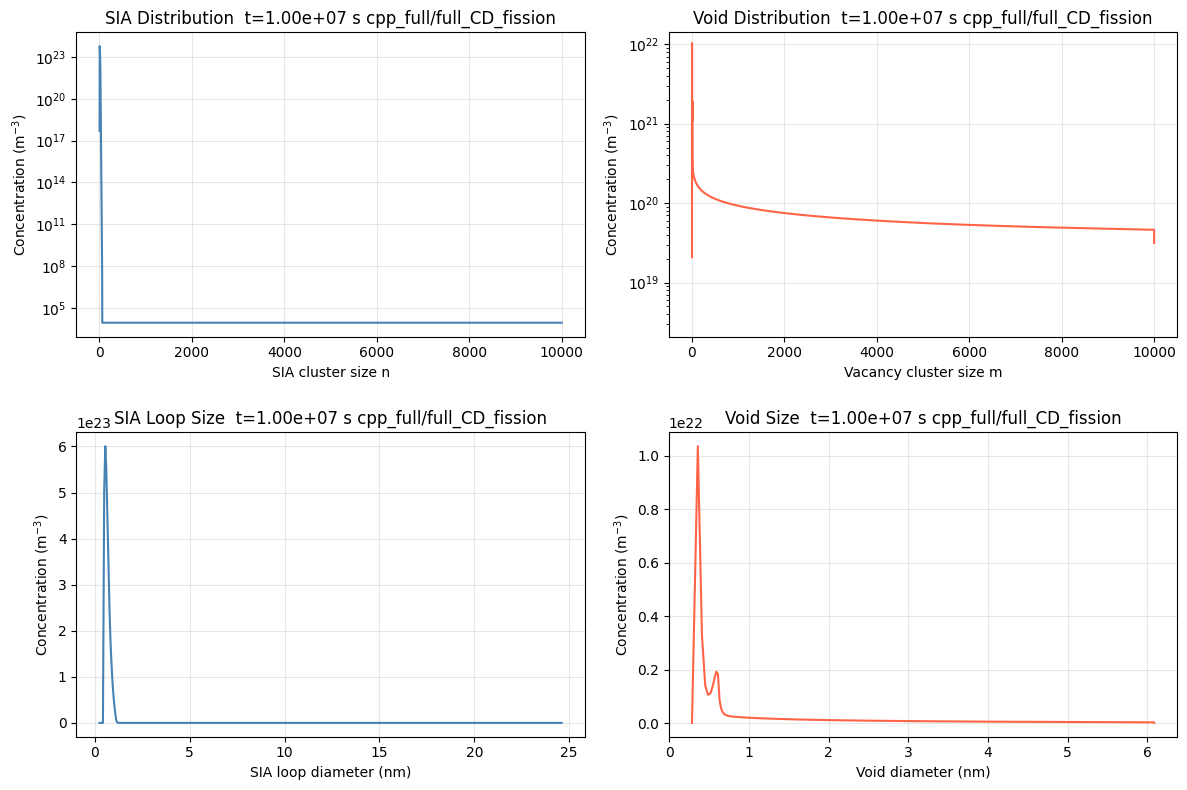

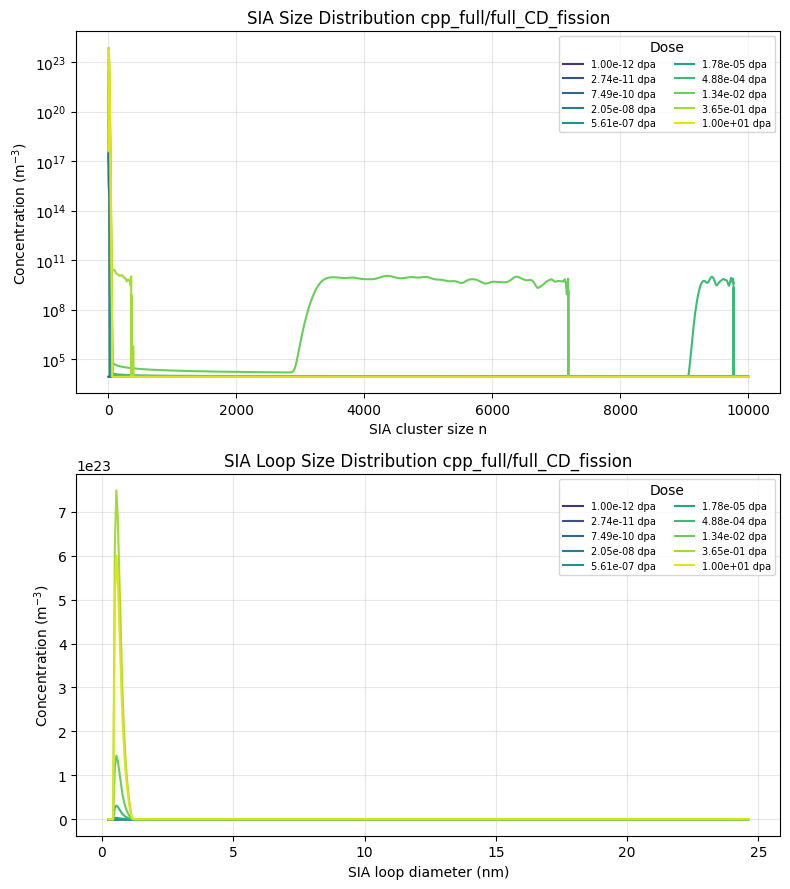

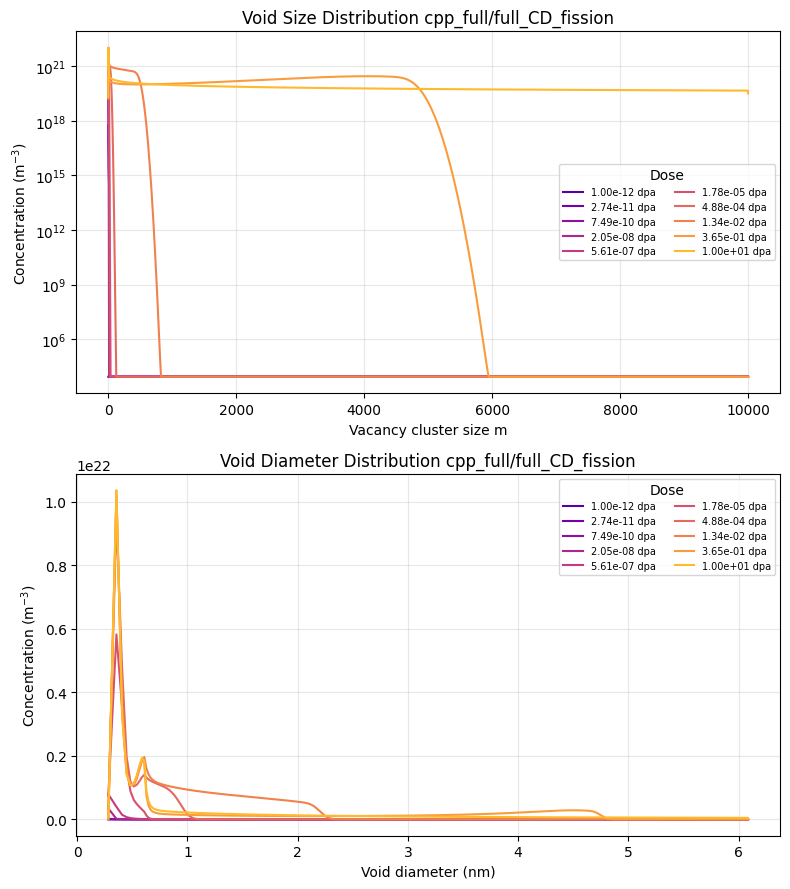

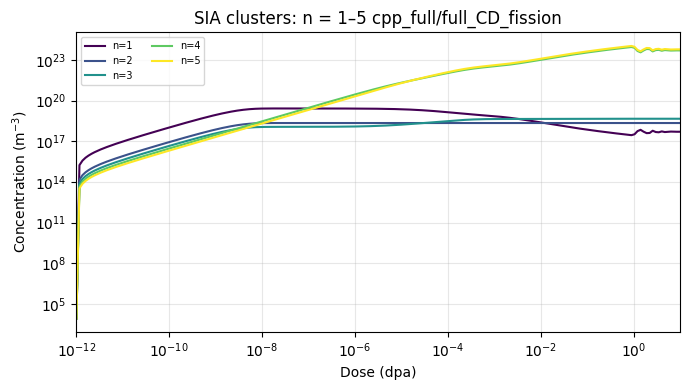

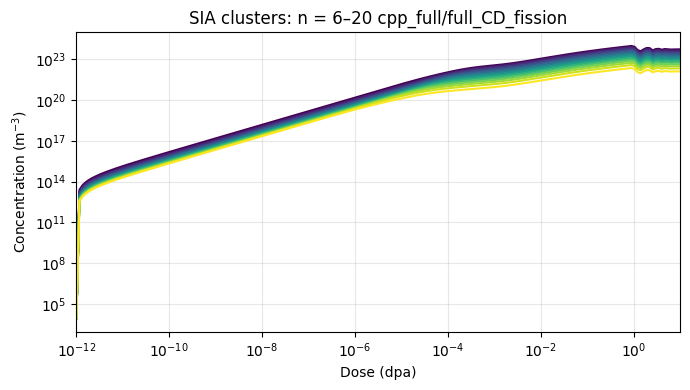

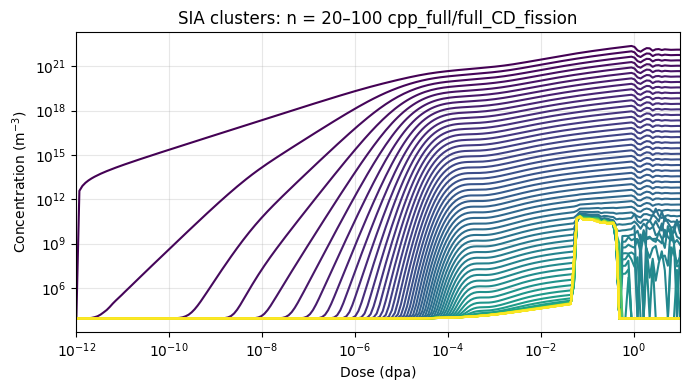

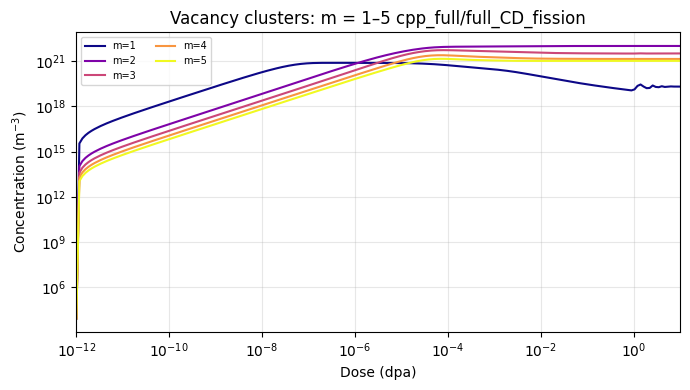

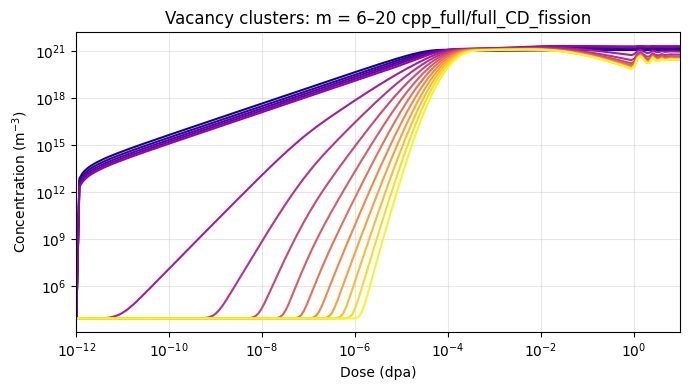

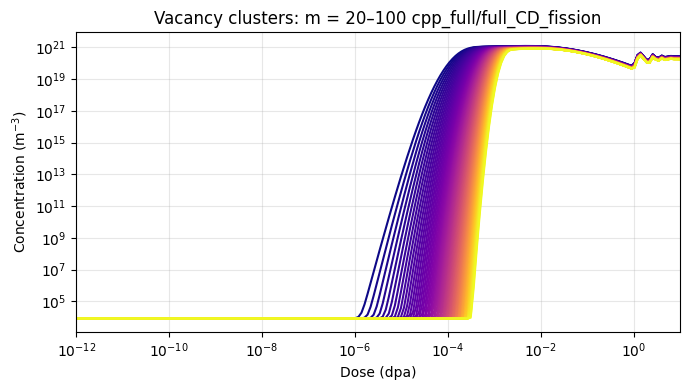

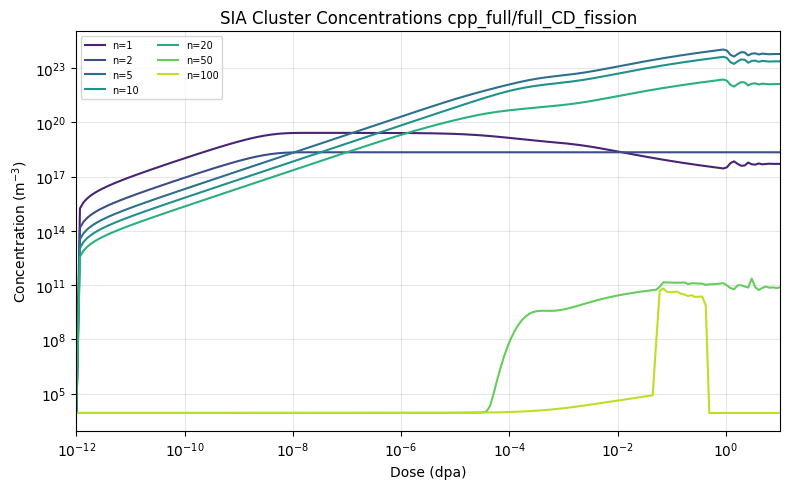

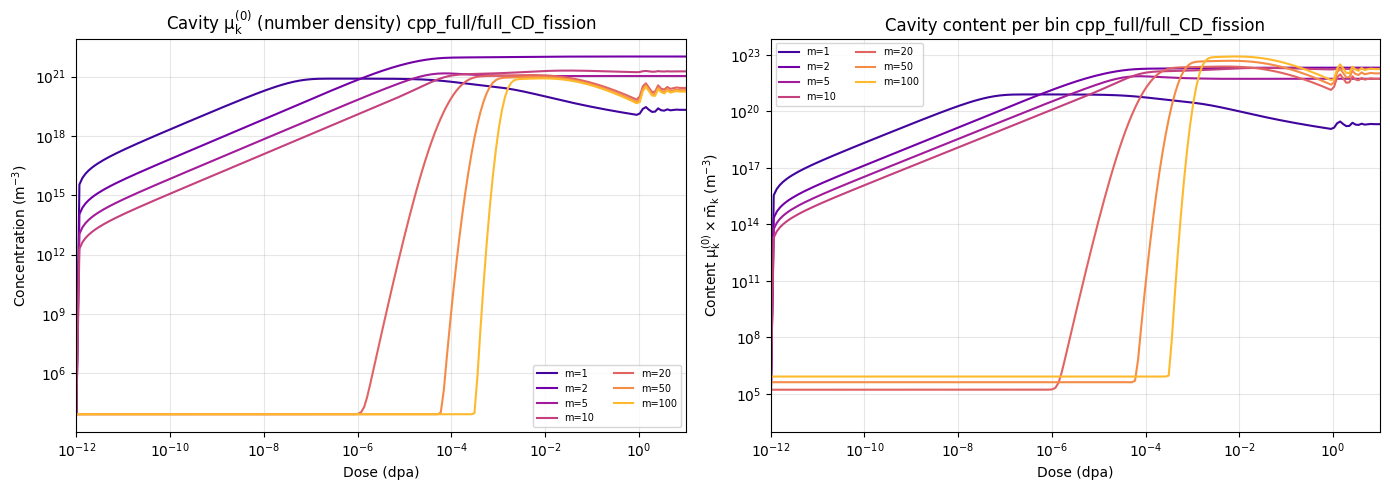

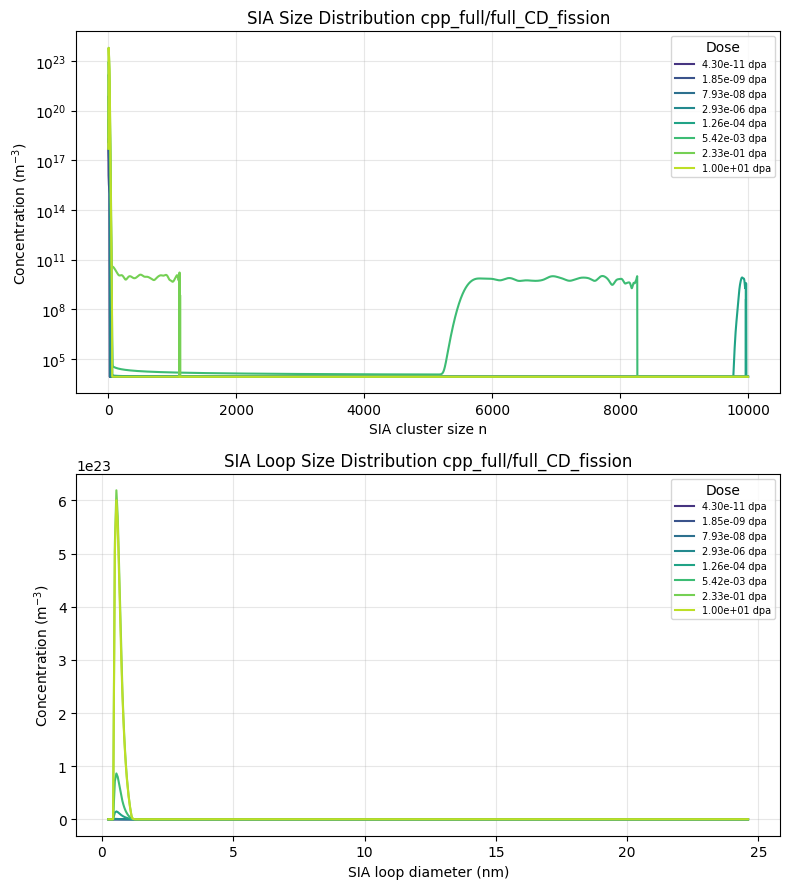

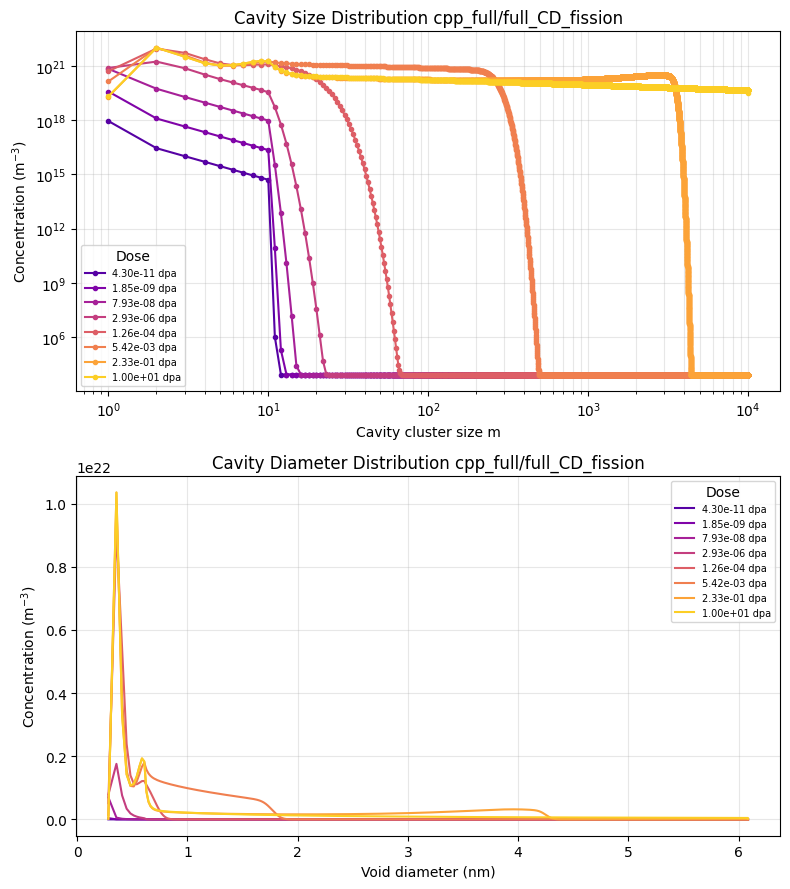

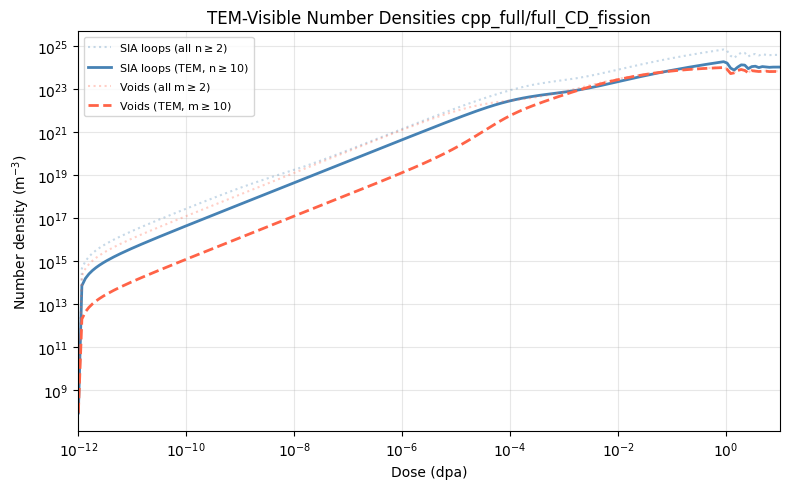

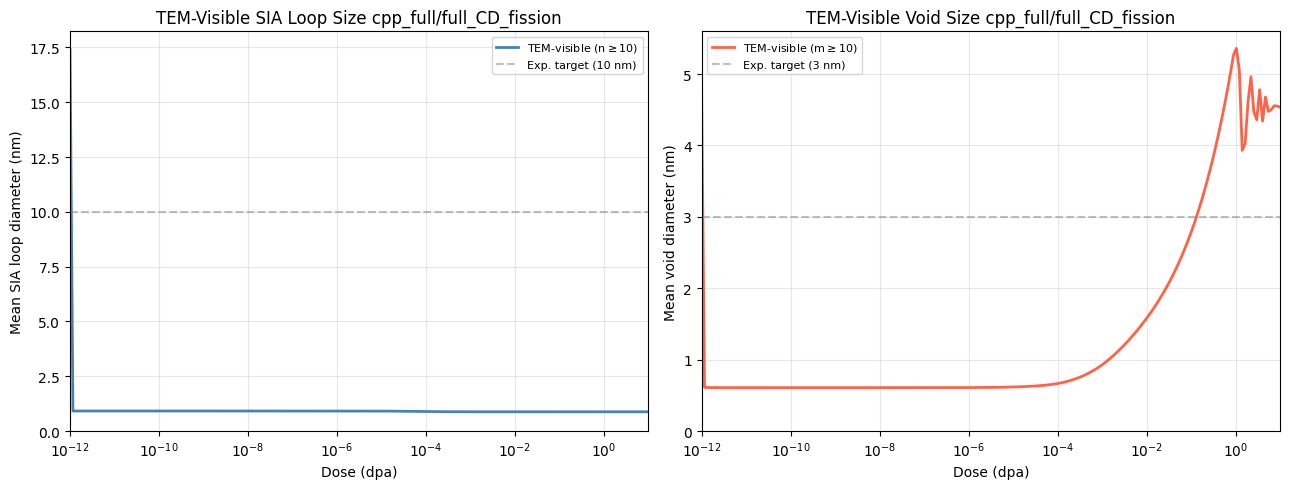

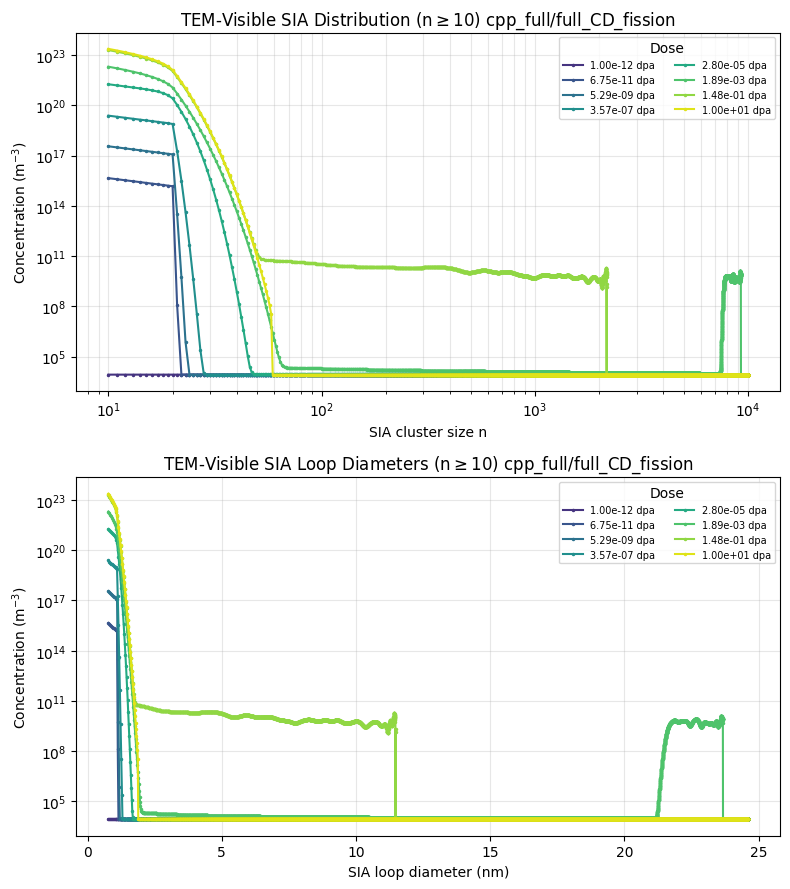

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# ENVIRONMENT SETUP
# ══════════════════════════════════════════════════════════════════════════════
import sys, os, io
from pathlib import Path

MODULE_ROOT = Path('../..').resolve()
REPO_ROOT   = MODULE_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

import numpy as np
import importlib

# Reload all py_utils modules to pick up code changes
import RadCluster_1_0.py_utils.defect_production as _dp_mod
import RadCluster_1_0.py_utils.binding_energies as _be_mod
import RadCluster_1_0.py_utils.bin_moment_rates as _bmr
import RadCluster_1_0.py_utils.input_data as _inp_mod
import RadCluster_1_0.py_utils.reaction_rates as _rr_mod
import RadCluster_1_0.py_utils.rate_equations as _re_mod
import RadCluster_1_0.py_utils.cpp_bridge as _cb_mod
import RadCluster_1_0.py_utils.post_process as _pp_mod
import RadCluster_1_0.py_utils.simulation as _sim_mod
import RadCluster_1_0.py_utils.visualization as viz
for _m in [_dp_mod, _be_mod, _bmr, _inp_mod, _rr_mod, _re_mod,
           _cb_mod, _pp_mod, _sim_mod, viz]:
    importlib.reload(_m)
from RadCluster_1_0.py_utils.simulation import RadClusterSimulation


# ══════════════════════════════════════════════════════════════════════════════
# 2. User selections — cluster domain and mobility
# ══════════════════════════════════════════════════════════════════════════════
DEBUG = False
SOLVER_MODE    = 'cpp_full' # or "sliding_OpenMP" or "cpp_sliding_window" or "cpp_full" or "python"
PHYSICS_OPTION = 'full_CD_fission' # 'full_CD_fusion' or 'bin_moment_CD_fission' or "bin_moment_CD_fusion"

# ── Domain sizes ─────────────────────────────────────────────────────────────
I          = int(10000)    # max SIA cluster size  (grows adaptively if doublings > 0)
V          = int(10000)    # max vacancy cluster size

# ── Mobility cutoffs ────────────────────────────────────────────────────────
i_mobile   = 1          # max mobile SIA cluster size
v_mobile   = 1          # max mobile vacancy cluster size

# ── Discrete / binned split ──────────────────────────────────────────────────
# Sizes 1..i_discrete tracked as individual ODEs; beyond that, bin moments.
# Defaults: i_discrete = i_mobile, v_discrete = v_mobile.
# Set I_bin = 0 and i_discrete = I to recover full_CD limit.
i_discrete = I    # max discrete SIA size
v_discrete = V    # max discrete vacancy size
I_bin      = 0         # SIA bin-moment equations (None = auto from r≈2)
V_bin      = 0         # VAC bin-moment equations (None = auto from r≈2)

# ── Other settings ───────────────────────────────────────────────────────────
C_FLOOR    = 1e-25       # concentration floor [atom fraction]
HE_OPTIONS = 'quasi_steady_state'


# ══════════════════════════════════════════════════════════════════════════════
# 3. Solver configuration


# ══════════════════════════════════════════════════════════════════════════════
SOLVER_CONFIG = {
    't_span':   (1e-6, 1e7),
    'n_points': 200,
    'log_time': True,
    'rtol':     1e-6,
    'atol':     1e-20,
    'solver_method': {
        'backend':           'cvode',
        'lmm':               'bdf',
        'linsol':            'gmres', #dense or gmres
        'max_order': 4,     # more robust through transients
        'window_w0_i':       50,
        'window_width':      200,
        'window_C_expand':   1e-18,
        'window_expand_pad': 100,
        'window_omp_threads':8,
        'window_prec':       1,
        'window_gmres_maxl': 50,
        'window_N_thresh':   500,
    }
}


# ══════════════════════════════════════════════════════════════════════════════
# 4. Initialize simulation (reads Excel file)
# ══════════════════════════════════════════════════════════════════════════════

_saved_out, _saved_err = sys.stdout, sys.stderr
if not DEBUG:
    sys.stdout = sys.stderr = io.StringIO()
try:
    sim = RadClusterSimulation(
        I=I, V=V,
        solver_mode=SOLVER_MODE,
        physics_option=PHYSICS_OPTION,
        C_floor=C_FLOOR,
        he_options=HE_OPTIONS,
        i_mobile=i_mobile,
        v_mobile=v_mobile,
    )
finally:
    sys.stdout, sys.stderr = _saved_out, _saved_err


# ══════════════════════════════════════════════════════════════════════════════
# 4b. Parameter overrides — applied AFTER reading Excel, BEFORE solver run.
#     Keys are the Symbol names from each Excel sheet.
#     Set PARAM_OVERRIDES = {} to use the Excel defaults.
# ══════════════════════════════════════════════════════════════════════════════

PARAM_OVERRIDES = {
    # ── Production sheet (fission) ────────────────────────────────────────
    'eta':       0.3,        # cascade survival efficiency (default 0.30)
    'f_cl_i':    0.2,       # SIA clustering fraction    (default 0.58)
    'f_cl_v':    0.15,       # vacancy clustering fraction (default 0.15)

    # ── Diffusion sheet ──────────────────────────────────────────────────
    'E_m_1D':    0.4,       # 1D SIA cluster migration energy [eV] (default 0.34)
    'i_mobile':  i_mobile,   # SIA mobility cutoff
    'L_hat':     5,       # mean free path L/a (default 50)
    'c_C':       1e-3,    # dissolved C concentration [at/at] (default 5e-4)
    'E_b_C_SIA': 0.65,       # C-SIA binding energy [eV] (default 0.45)

    # ── Reactions sheet ──────────────────────────────────────────────────
    'rho_d':     1e15,       # dislocation density [m^-2] (default 1e13)
    'Z_i':       1.08,        # SIA dislocation bias factor (default 1.1)
    'Z_ii':      1.01,        # SIA-SIA coalescence bias factor (default 1.0)
    'shape_function': 'linear',  # 'constant', 'linear', or 'lognormal'
   # 'boundary_flux': 'reflection',   # or 'absorption' (default)
}

# Inject discrete/bin controls into overrides
PARAM_OVERRIDES['i_discrete'] = i_discrete
PARAM_OVERRIDES['v_discrete'] = v_discrete
if I_bin is not None:
    PARAM_OVERRIDES['I_bin'] = I_bin
if V_bin is not None:
    PARAM_OVERRIDES['V_bin'] = V_bin

if PARAM_OVERRIDES:
    _saved_out2, _saved_err2 = sys.stdout, sys.stderr
    if not DEBUG:
        sys.stdout = sys.stderr = io.StringIO()
    try:
        inp = sim.input_data
        for key, val in PARAM_OVERRIDES.items():
            placed = False
            for d in [inp.production_fission, inp.production_fusion,
                      inp.diffusion, inp.reactions,
                      inp.energetics, inp.dissociation]:
                if key in d:
                    d[key] = val
                    placed = True
            if not placed:
                inp.reactions[key] = val
        if 'i_mobile' in PARAM_OVERRIDES:
            inp.diffusion['i_mobile'] = int(PARAM_OVERRIDES['i_mobile'])
            inp.reactions['i_mobile'] = int(PARAM_OVERRIDES['i_mobile'])
        inp._calculate_derived()
        sim.rebuild_rates()
    finally:
        sys.stdout, sys.stderr = _saved_out2, _saved_err2

    print(f'Applied {len(PARAM_OVERRIDES)} parameter overrides:')
    for k, v in PARAM_OVERRIDES.items():
        print(f'  {k:>12} = {v}')
else:
    print('Using Excel defaults (no overrides)')

# ── Report system size ────────────────────────────────────────────────────
re = sim.rate_equations
if hasattr(re, 'I_bin'):
    P = re.n_mom
    print(f'\nHybrid discrete + bin-moment system (shape_function={re.shape_function!r}):')
    print(f'  Discrete SIA:  i = 1..{re.i_discrete}  ({re.i_discrete} ODEs)')
    print(f'  Binned SIA:    I_bin = {re.I_bin}  ({P} moments each = {P*re.I_bin} ODEs)')
    print(f'  Discrete VAC:  v = 1..{re.v_discrete}  ({re.v_discrete} ODEs)')
    print(f'  Binned VAC:    V_bin = {re.V_bin}  ({P} moments each = {P*re.V_bin} ODEs)')
    he_odes = re.N_eq - (re.i_discrete + P*re.I_bin + re.v_discrete + P*re.V_bin)
    print(f'  He state:      {he_odes} ODE(s)')
    print(f'  ──────────────────────')
    print(f'  Total N_eq = {re.N_eq}  (full_CD would be {sim.input_data.I + sim.input_data.V + 2})')
else:
    print(f'\nFull per-size system: N_eq = {re.N_eq}')


# ══════════════════════════════════════════════════════════════════════════════
# 5. Build live progress callback
# ══════════════════════════════════════════════════════════════════════════════
sim._progress_rows = []

rr      = sim.reaction_rates
rate_eq = sim.rate_equations
G_dpa   = sim.input_data.derived['G']
Omega   = sim.input_data.derived['Omega']
s2m     = 1.0 / Omega

_row_idx = [0]

def _progress_callback(row):
    sim._progress_rows.append(dict(row))
    j   = _row_idx[0];  _row_idx[0] += 1
    t_  = row.get('t', 0.0)
    dos = t_ * G_dpa
    if DEBUG:
        ci1 = row.get('c_i1', 0.0)
        cv1 = row.get('c_v1', 0.0)
        sys.stderr.write(
            f'  [{j:>4d}] t={t_:.4e}  dose={dos:.3e}'
            f'  Ci1={ci1*s2m:.3e}  Cv1={cv1*s2m:.3e} m^-3\n')
        sys.stderr.flush()


# ══════════════════════════════════════════════════════════════════════════════
# 6. Run simulation — TRULY ADAPTIVE CONTINUATION
#    Integration runs in short segments (points_per_segment output points
#    each).  After every segment the tail fraction is checked.  When the
#    threshold is first exceeded, I and/or V are doubled and
#    integration CONTINUES from that time point — no restart from t=0.
#    I and V have independent doubling budgets.
#
#    Graceful interrupt: press Ctrl+C (or Jupyter "Interrupt Kernel") at
#    any time.  The C++ subprocess is terminated, all completed segments
#    are kept, and results / plots are saved for the last integration point.
# ══════════════════════════════════════════════════════════════════════════════
%matplotlib inline

# results = sim.run_adaptive(
results = sim.run(
    solver_config=SOLVER_CONFIG,
    save_output=False,           # defer saving — we handle it below
    progress_callback=_progress_callback,
#     boundary_threshold=0.05,      # adapt if >5% of content at boundary
#     max_doublings=8,             # 0 = no adaptive doubling
#     points_per_segment=50,       # check every 50 output points
)



# Fallback: if run_adaptive returned None (e.g. interrupt before any segment
# completed), try the internally accumulated partial results.
if results is None:
    results = sim._accumulated_results

if results is not None:
    t_arr = results['t']
    I_final = sim.input_data.I
    V_final = sim.input_data.V
    print(f'\nFinal domain: I={I_final}  V={V_final}')
    print(f'Solution:         {len(t_arr)} time points, '
          f't = [{t_arr[0]:.2e}, {t_arr[-1]:.2e}] s')
    print(f'Final dose:       {results["dose"][-1]:.4e} dpa')
    print(f'Swelling (final): {results["swelling"][-1]*100:.6f} %')
    print(f'C_He_tot (final): {results["C_He_tot"][-1]:.3e} m^-3')
    print(f'mean_n_i (final): {results["mean_n_i"][-1]:.2f}')
    print(f'mean_n_v (final): {results["mean_n_v"][-1]:.2f}')
    print(f'N_loops  (final): {results["N_loops"][-1]:.3e} m^-3')
    print(f'N_voids  (final): {results["N_voids"][-1]:.3e} m^-3')
    print(f'delta_FP (final): {results["delta_FP"][-1]:.3e}  (Eq. 164)')
    print(f'delta_He (final): {results["delta_He"][-1]:.3e}  (Eq. 165)')

    # Save output (provenance, CSV, diagnostics, .npy, plots)
    sim._diag_text = sim.reaction_rates.format_diagnostic(
        mean_n_i=results['mean_n_i'][-1]
        if 'mean_n_i' in results else None)
    sim._save_output(results, SOLVER_CONFIG)
else:
    print('Simulation failed -- check C++ build and parameter file.')